[INFO] Memuat Dataset INDONESIA DOMAIN: extracted_data_1c_4_final.json


2026-07-25 18:24:10.562228: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-25 18:24:10.562254: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-25 18:24:10.562263: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-25 18:24:10.562289: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-25 18:24:10.562304: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
Estimating INDONESIA DOMAIN embeddings statistics (KDE)...
Memproses 5601 data INDONESIA DOMAIN...
Inference INDONESIA DOMAIN: 100%|██████████| 5601/5601 [00:50<00:00, 111.93it/s]

INDONESIA DOMAIN ACCURACY: None
INDONESIA DOMAIN F1-SCORE: None
Pengujian INDONESIA DOMAIN Selesai.


Accuracy: [0.582842349580432, 0.582842349580432]
Accuracy (avg.): 0.582842349580432
True positive rate: [0.908766291733619, 0.25691840742724514]
True positive rate (avg.): 0.582842349580432
True negative rate: [0.25691840742724514, 0.908766291733619]
True negative rate (avg.): 0.582842349580432
Positive predictive value: [0.550151318633809, 0.737948717948718]
Positive predictive value (avg.): 0.6440500182912634
Negative predictive value: [0.737948717948718, 0.550151318633809]
Negative predictive value (avg.): 0.6440500182912634
False positive rate: [0.7430815925727549, 0.091233708266381]
False positive rate (avg.): 0.4171576504195679
False negative rate: [0.091233708266381, 0.7430815925727549]
False negative rate (avg.): 0.4171576504195679
False discovery rate: [0.4498486813661911, 0.26205128205128203]
False discovery rate (avg.): 0.3559499817087366
F1-score: [0.6853834242240625, 0.38114157065289367]
F1-score (avg.): 0.5332624974384781
[DEBUG] Nilai yang akan diplot: [0.582842349580432

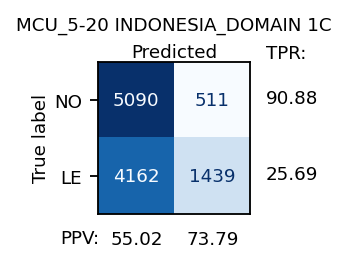

In [1]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt

# Fungsi untuk membuat diagram batang metrik komprehensif
def plot_comprehensive_metrics(metrics, save_path):
    # Mapping nama label ke key yang tepat sesuai output Anda
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    
    # Mengambil nilai berdasarkan key yang tepat
    values = [metrics.get(k, 0) for k in keys]
    
    print(f"[DEBUG] Nilai yang akan diplot: {values}") 

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Average)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Tambahkan angka di atas batang
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
                
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik komprehensif tersimpan di: {save_path}")

# Main execution
if __name__ == "__main__":


                  
    #===================================================================
    #                    1. KONFIGURASI PATH STEAD
    #===================================================================
    # Path dataset sesi 1
    #KEY_DATA_DIR = "/Volumes/Extreme SSD/output_json_indonesia"
    #KEY_TEST_FILE = "extracted_data.json" 
    
    # ===================================================================
    # Konfigurasi untuk pengujian INDONESIA DOMAIN sesi 3
    #===================================================================

    #KEY_DATA_DIR = '/Volumes/Extreme SSD/unduhan_waveform_merged'
    #KEY_TEST_FILE = 'extracted_data.json'

    KEY_DATA_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4'
    KEY_TEST_FILE = "extracted_data_1c_4_final.json"

    DATA_TAG = "INDONESIA_DOMAIN"
    MODEL_TAG = "MCU_5-20"
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    
    # STEAD fokus pada Noise (NO) dan Earthquake (LE)
    true_labels = ["NO", "LE"]
    source_to_code = {"noise": 0, "le": 1}

    # Path Model dan Embedding (PASTIKAN MENGGUNAKAN EMBEDDING STEAD)
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    # Path Embedding Khusus STEAD (n=61099) atau UUSS (n=11275) opsi: gunakan salah satu, jangan keduanya
    #EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538")
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")
    #===================================================================
    #                           2. PREPARE FILES
    #===================================================================
    print(f"[INFO] Memuat Dataset INDONESIA DOMAIN: {KEY_TEST_FILE}")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    SAVE_BASE = SAVE_BASE = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/output/nUUSS_embedding_1c_4_final'
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    if not os.path.exists(save_dir): os.makedirs(save_dir)

    # Logger
    log_file_path = os.path.join(save_dir, "task_log_indonesia_domain.txt")
    logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load Model & Embeddings STEAD
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

    logger.info(f"Estimating INDONESIA DOMAIN embeddings statistics (KDE)...")
    # Menggunakan statistik ruang laten INDONESIA DOMAIN
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    #===================================================================
    #                            3. EVALUATION
    #===================================================================
    total_true_3C, total_pred_3C = [], []
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    keys_list = list(test_data.keys())

    logger.info(f"Memproses {len(keys_list)} data INDONESIA DOMAIN...")

    for i in tqdm(range(len(keys_list)), desc="Inference INDONESIA DOMAIN"):
        record_key = keys_list[i]
        record = test_data[record_key]
        quake_label = record["type"] # label asli: 'le'
    
        try:
            # Hanya ambil Z
            Z_n = record["Z_noise"][-num_points:]
            Z_s = record["Z"][:num_points]

            # Embedding Z saja
            _in_Zn = utils.latent_codes_1D(Z_n, embedding_model)
            _in_Zs = utils.latent_codes_1D(Z_s, embedding_model)

            # Karena model MCU-Quake 3C mengharapkan 3 komponen, 
            # kita berikan Z untuk ketiga slot input (E, N, Z) sebagai workaround
            emb_n = np.array([_in_Zn, _in_Zn, _in_Zn]).reshape(1,-1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zn, _in_Zn, _in_Zs]).reshape(1,-1) # Z_s untuk Z
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            total_true_3C.extend([0, 1]) 
            total_pred_3C.extend([1 if p_n >= 1 else 0, 1 if p_s >= 1 else 0])
            
        except Exception as e:
            logger.error(f"Error pada {record_key}: {e}")
            continue

    #===================================================================
    #                        4. METRICS & SAVE
    #===================================================================

    matrix_1C, metrics_1C = utils.calc_confusion_metrics(total_true_3C, total_pred_3C)
    
    # Visualisasi
    fig_1C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 1C", true_labels, matrix_1C, metrics_1C)
    fig_1C.savefig(os.path.join(save_dir, "Indonesia_domain_1C.jpg"), dpi=300)
    
    dataset.save_json_data(os.path.join(save_dir, "indonesia_domain_metrics.json"), metrics_1C)
    # Plot comprehensive metrics
    plot_comprehensive_metrics(metrics_1C, os.path.join(save_dir, "indonesia_domain_1C_metrics_bar.jpg"))

        
    logger.info("\n" + "="*40)
    logger.info(f"INDONESIA DOMAIN ACCURACY: {metrics_1C.get('accuracy (avg.)')}")
    logger.info(f"INDONESIA DOMAIN F1-SCORE: {metrics_1C.get('f1-score (avg.)')}")
    logger.info("="*40)
    logger.info("Pengujian INDONESIA DOMAIN Selesai.")


   